# Bispectrum and bicoherence and biphase

## Summary

Bicoherence is a squared, normalized version of the bispectrum. Bicoherence is real and normalized between 0 and 1. Bicoherence measure how much phase coupling / "locking" there is between signals. In the following, we consider auto-bispectrum and auto-bicoherence - i.e. the phase coupling between different frequency components in the same signal. The bispectrum and bicoherence can also be computed for 2 different signals.

The strength of the bicoherence is to discover the "hidden signature" of nonlinear processes in a signal. If 3 frequencies $f1$, $f2$, $f3=f1+f2$ are present in a signal and visible in its power spectral density (PSD), and $f3$ is the result of a nonlinear (for example, cross product) interaction between $f1$ and $f2$, then the bicoherence will have a peak for the triplet $(f1, f2, f3)$. If there is no peak at this triplet, then $f3$ is not the result of a nonlinear interaction between $f1$ and $f2$. Note that having a bicoherence peak is a necessary, not a sufficient, condition for a non-linear interaction to be present.

## Definitions

### Bispectrum

$B(f_1, f_2) = F(f_1) . F(f_2) . F^*(f_1+f_2)$  , with $f_1$ and $f_2$ the 2 frequencies considered, $B$ the bispectrum, $F$ the Fourier transform, $^*$ the complex conjugate.

A $F$ transform results in a complex vector. From standard complex calculations, the $B$ magnitude is the product of the $F$ magnitudes, and the $B$ phase is the sum of the $F$ phases (with a - for the $^*$ one).

## Bicoherence

The bicoherence is obtained by averaging over several bispectra, and normalizing. There are several ways to do the normalization. We will prefer the "absolute norm" normalization:

$b(f_1, f_2) = abs(sum_n(B_n(f_1, f_2)) / sum_n(abs(B_n(f_1, f_2)))$  , with $b$ the bicoherence, $B_n(f_1, f_2)$ the bicoherence spectrum on segment number $n$ at frequencies $f_1$ and $f_2$, $sum_n$ the sum over the $n$ segments.

## Biphase

The biphase is the average phase of the bispectrum, obtained by averaging the bispectrum over the segments then computing the phase. The biphase is only meaningful where the bicoherence is high. The biphase tells what the relative phase between the signal components $S_1$, $S_2$, and $S_3$ is.

### Interpretation

Considering a signal that is stationary in time:

- if the signal components at frequencies $f_1$, $f_2$, $f_3$, are not phase locked, then the phase of the $B_n(f_1, f_2)$ will be random, and the $sum_n(B_n(f_1, f_2)$ will average to $0$ at the limit; hence, the bicoherence will be $0$
- if the signal components at frequencies $f_1$, $f_2$, $f_3$ are phase locked, then the phase of the $B_n(f_1, f_2)$ will be constant, and the $abs(sum_n(B_n(f_1, f_2))$ will average to $n . abs(B_n(f_1, f_2))$; so does the denominator, so the bicoherence will be $1$.
- there are other ways to normalize and compute the bicoherence, which may make the signals stand out more - for example, using some variation of the square instead of the absolute norm. See the wiki link below.

So a bicoherence of $0$ indicates that the signals at $f_1$, $f_2$, $f_3$ are not phase locked / coupled, and a bicoherence of $1$ indicate that they are fully phase locked / coupled.

Note that this is a necessary, but not a sufficient, condition for frequency components to be coupled by a non-linear mechanism (like "correlation is not causation").

If the bicoherence is higher than 0, the biphase indicate the average phase.

### Possible extensions

This could be extended to

- the coupling of modes across 2 different signals: consider $F_f(f1)$, $F_f(f2)$, and $F_g(f1+f2)$, with $f$ and $g$ the two input signals
- in the case of 2 different signals, different sampling frequencies for the 2 of them

## Sources

- https://en.wikipedia.org/wiki/Bicoherence

## Implementation of the bispectrum and bicoherence

## Illustration of bicoherence use for discovering nonlinear cross couplings

Let us illustrate what can be obtained with the bicoherence analysis.

For this, we will:

- write a function $G = generate\_realization\_from\_PSD$ that generates a pseudo random realization of a given PSD, following / extending the method described in https://dsp.stackexchange.com/a/93191 , i.e.:
    - randomizing for each frequency bin both the phases (uniform $[0-2 \pi]$) and the amplitudes (applying a random gaussian scaling to each bin) each time a realization is produced,
    - producing the signal using a series of consecutive overlapping segments to make sure there is no phase locking across the whole signal,
    - using windowing to avoid jumps between the segments,
    - removing the first and last havf window length to avoid transient periods with reduced amplitude
- use $G$ to generate 2 pseudo random signals, $S1$ and $S2$, with some significant energy around respective frequencies $f1$ (for $S1$) and $f2$ (for $S2$)
- generate a new signal $S3 = S1 + S2 + \alpha * S1 * S2$, i.e. it includes a cross term / non-linear coupling between the signals at $f1$ and $f2$
- take the spectrum of $S3$, and use $G$ to generate a pseudo random signal with the same PSD, $S3'$
- compare the bicoherence of $S3$ and $S3'$; we expect that the bicoherence for $S3$ will give a significant peak for the triplet $(f1, f2, f1+f2)$, but that this peak will not be present in $S3'$. This illustrates that bicoherence is able to detect the signature of non-linear terms in data.

In [1]:
from bicoherence import compute_auto_bicoherence, compute_auto_biphase
from realization_from_psd import generate_realization_from_PSD

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

import math

/home/jeanr/conda/envs/dev/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jeanr/conda/envs/dev/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


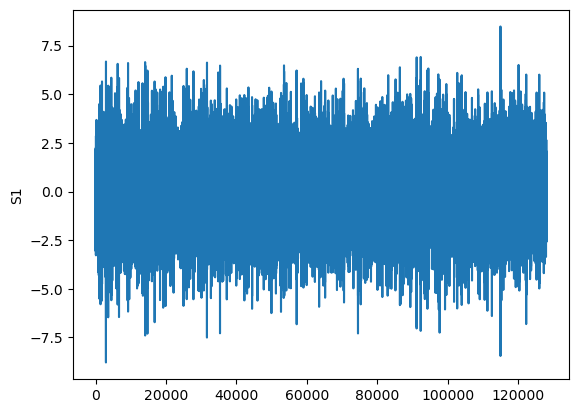

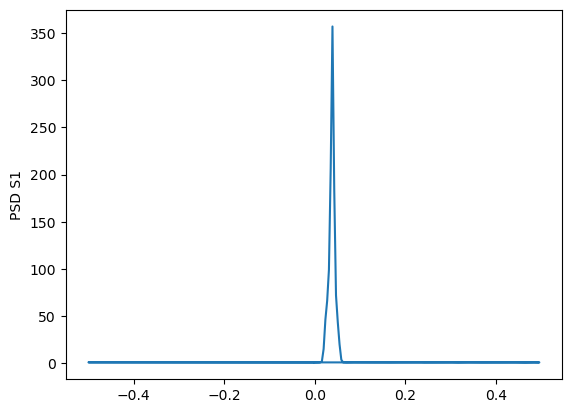

/home/jeanr/conda/envs/dev/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jeanr/conda/envs/dev/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


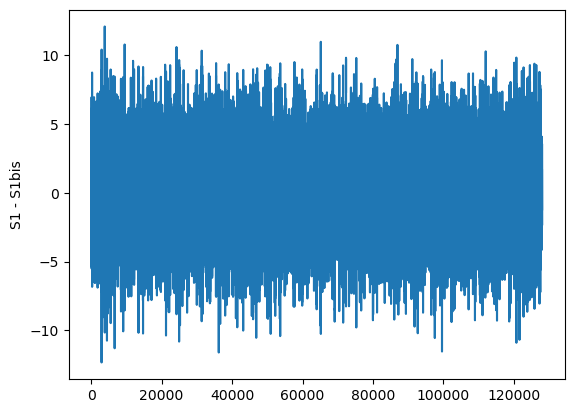

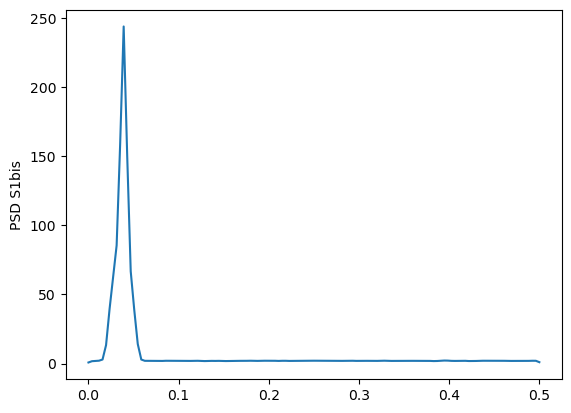

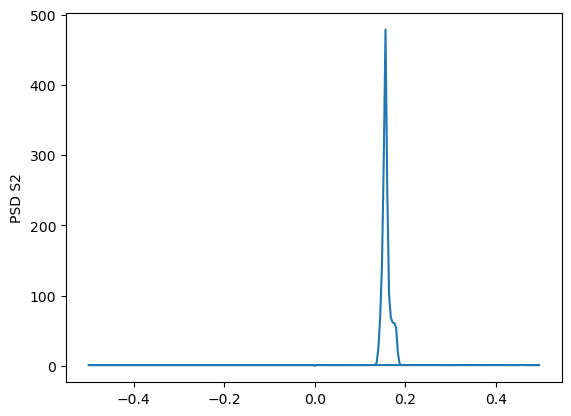

In [2]:
segment_length = 2**8
total_number_segments = 1000
psd_peak_strength = 10
phase_noise_level = math.pi / 4.0

real = False

# ------------------------------------

psd_1 = np.full((segment_length,), 1.0)
f1 = 10
mag_signal_f1 = psd_peak_strength
psd_1[f1-4:f1+4] = mag_signal_f1*5.0
psd_1[f1-2:f1+2] = mag_signal_f1*10.0
psd_1[f1] = mag_signal_f1*40.0
# phase = None  # option 1: random phase
phase = 15 * math.pi * np.full(psd_1.shape, 1.0)  # option 2: stochastic phase (rad)

signal_1 = generate_realization_from_PSD(psd=psd_1, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments, phase=phase, real=real, phase_noise_level=phase_noise_level)

plt.figure()
plt.plot(signal_1)
plt.ylabel("S1")
plt.show()

signal_1_welch_freq, signal_1_welch_psd = sp.signal.welch(signal_1, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_1_welch_freq, signal_1_welch_psd)
plt.ylabel("PSD S1")
plt.show()

# note that if you repeat, you get a similar but different PSD, as should be

signal_1_bis = generate_realization_from_PSD(psd=psd_1, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

plt.figure()
plt.plot(signal_1-signal_1_bis)
plt.ylabel("S1 - S1bis")
plt.show()

signal_1_welch_freq_bis, signal_1_welch_psd_bis = sp.signal.welch(signal_1_bis, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_1_welch_freq_bis, signal_1_welch_psd_bis)
plt.ylabel("PSD S1bis")
plt.show()

# ------------------------------------

psd_2 = np.full((segment_length,), 1.0)
f2 = 40
mag_signal_f2 = psd_peak_strength * 2
psd_2[f2-3:f2+7] = mag_signal_f2*3.0
psd_2[f2-2:f2+2] = mag_signal_f2*7.0
psd_2[f2] = mag_signal_f2*30.0
# phase = None  # option 1: random phase
phase = 40 * math.pi * np.full(psd_1.shape, 1.0)  # option 2: stochastic phase (rad)

signal_2 = generate_realization_from_PSD(psd=psd_2, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments, phase=phase, real=real, phase_noise_level=phase_noise_level)

if False:
    plt.figure()
    plt.plot(signal_2)
    plt.ylabel("S2")
    plt.show()

signal_2_welch_freq, signal_2_welch_psd = sp.signal.welch(signal_2, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_2_welch_freq, signal_2_welch_psd)
plt.ylabel("PSD S2")
plt.show()

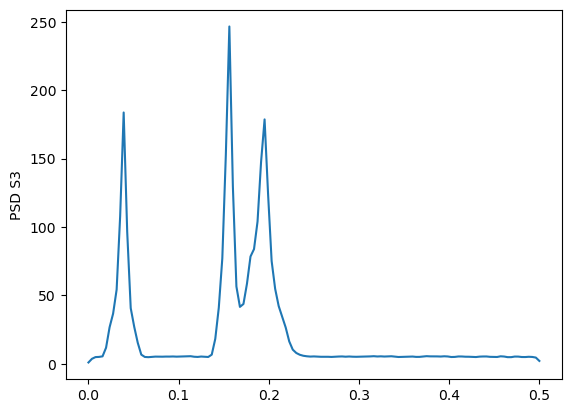

In [3]:
alpha = 0.5

phase_difference_harmonic_deg = 135.0
signal_3 = np.real(signal_1 + signal_2 + alpha * signal_1 * signal_2 * np.exp(-1j * phase_difference_harmonic_deg * math.pi / 180.0))

signal_3_welch_freq, signal_3_welch_psd = sp.signal.welch(signal_3, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_3_welch_freq, signal_3_welch_psd)
plt.ylabel("PSD S3")
plt.show()

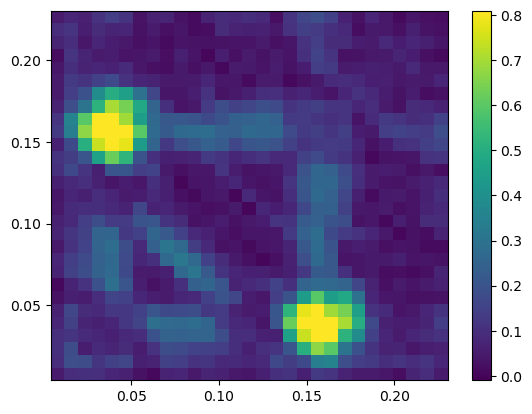

In [4]:
method = "absolute_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.clim([-0.01,0.81])
plt.colorbar()
plt.show()

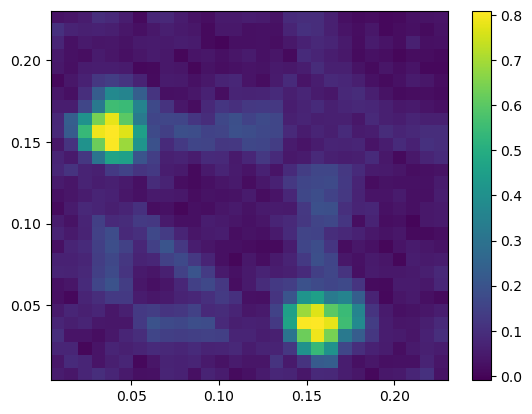

In [5]:
method = "square_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, window=np.hanning, segment_length=segment_length//2, n_overlap=segment_length//8, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.clim([-0.01,0.81])
plt.colorbar()
plt.show()

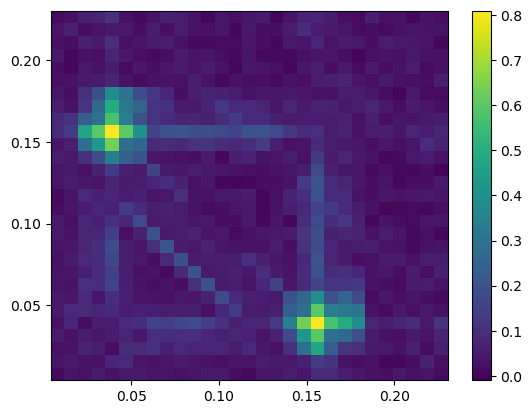

In [6]:
# note that a number of choices can influence the exact result - see for example here no window (None) instead of a Hanning one
# but the general result remains the same

method = "square_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, window=None, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.clim([-0.01,0.81])
plt.colorbar()
plt.show()

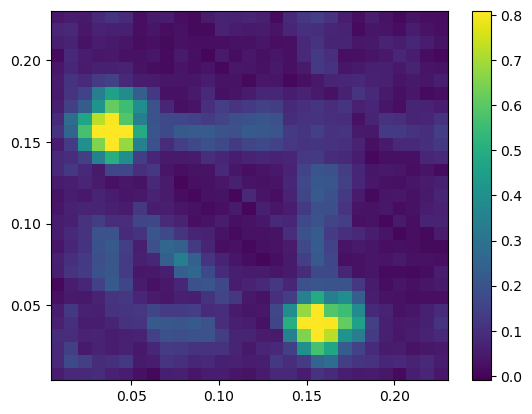

In [7]:
method = "square_norm_indep"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.clim([-0.01,0.81])
plt.colorbar()
plt.show()

## Compare with another package

In [8]:
from polycoherence import _plot_signal, polycoherence, plot_polycoherence

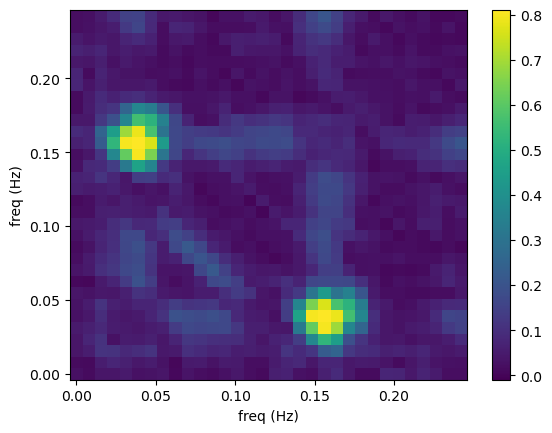

In [9]:
# in this package, the norm 2 seems to work well... getting similar results
freq1, freq2, bispec = polycoherence(data=signal_3, fs=1.0, norm=2, window="hann", nperseg=segment_length//2, noverlap=segment_length//4, nfft=segment_length//2)
df1 = freq1[1] - freq1[0]
df2 = freq2[1] - freq2[0]
freq1 = np.append(freq1, freq1[-1] + df1) - 0.5 * df1
freq2 = np.append(freq2, freq2[-1] + df2) - 0.5 * df2

plt.figure()
plt.pcolormesh(freq2, freq1, np.abs(bispec))
plt.xlabel('freq (Hz)')
plt.ylabel('freq (Hz)')
plt.clim([-0.01,0.81])
plt.colorbar()

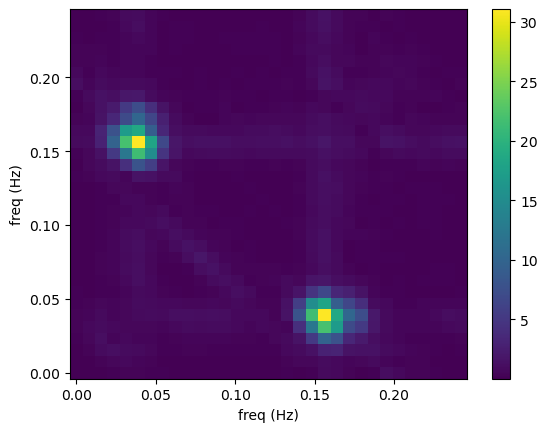

In [10]:
# ... but the norm1 may have normalization issues?
freq1, freq2, bispec = polycoherence(data=signal_3, fs=1.0, norm=1, window="hann", nperseg=segment_length//2, noverlap=segment_length//4, nfft=segment_length//2)
df1 = freq1[1] - freq1[0]
df2 = freq2[1] - freq2[0]
freq1 = np.append(freq1, freq1[-1] + df1) - 0.5 * df1
freq2 = np.append(freq2, freq2[-1] + df2) - 0.5 * df2

plt.figure()
plt.pcolormesh(freq2, freq1, np.abs(bispec))
plt.xlabel('freq (Hz)')
plt.ylabel('freq (Hz)')
# plt.clim([-0.01,0.81])
plt.colorbar()

### Look at the biphase

A high bicoherence indicates that there is phase locking between the signal components at $f_1$, $f_2$ and $f_3$. The actual value of the phase $angle(F(f_1) . F(f_2) . F^*(f_1+f_2))$ is provided by the byphase. See the docstring and code comments for more information about the ways to compute biphase with $compute\_auto\_biphase$; we recommend sticking to the "mean_then_angle" method, and masking points where the bicoherence is low (the biphase value is meaningful only where bicoherence is large).

Note that the conventions in the initial problem being studied can easily change angles by 90 degrees and / or a + or - sign; make sure to check the consistency of the conventions used in the application and in the code.

Below, we illustrate the value of the biphase for the test signal $S_3$: observe the good match between the biphase blob at the location of the bicoherence blob, and what was set in the synthetic signal $S_3$ generation above.

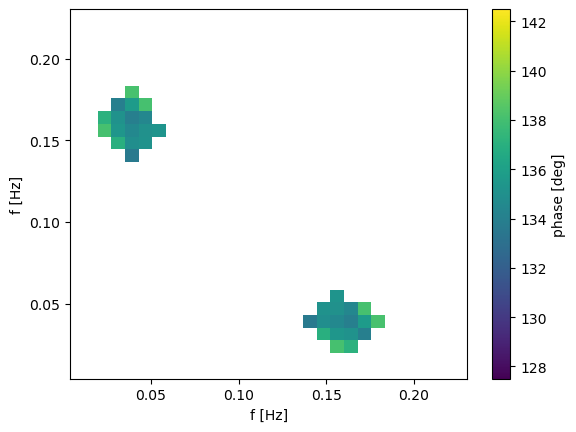

In [11]:
# TODO: explain in text above

biphase_method = "mean_then_angle"
# biphase_method = "angle_then_mean"

low_bicoherence_threshold_method = "square_norm_indep"
hide_low_bicoherence_threshold = 0.4

f1, f2, ph = compute_auto_biphase(signal_3, sample_frequency=1.0, window=np.hanning, segment_length=segment_length//2, \
                                  n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], biphase_method=biphase_method, \
                                  plot_distribution_peak=True, hide_low_bicoherence_threshold=hide_low_bicoherence_threshold, \
                                  low_bicoherence_threshold_method=low_bicoherence_threshold_method)

plt.figure()
width_around_expected_deg = 7.5
plt.pcolormesh(f1, f2, np.transpose(ph) * 180.0 / math.pi, shading='nearest', vmin=phase_difference_harmonic_deg-width_around_expected_deg, vmax=phase_difference_harmonic_deg+width_around_expected_deg)
# plt.clim([-0.01,0.81])
plt.xlabel("f [Hz]")
plt.ylabel("f [Hz]")
plt.colorbar(label="phase [deg]")
plt.show()

### Look at the result with S3', same PSD but no cross term

$S3'$ has nearly the same PSD (difference is rounding, stochasticity, etc) as $S3$, but a very different bicoherence: no peak whatsoever in the bicoherence, since the secondary peaks do not correspond to nonlinear terms, only to independant components. As a consequence, there is no significant bicoherence anywhere.

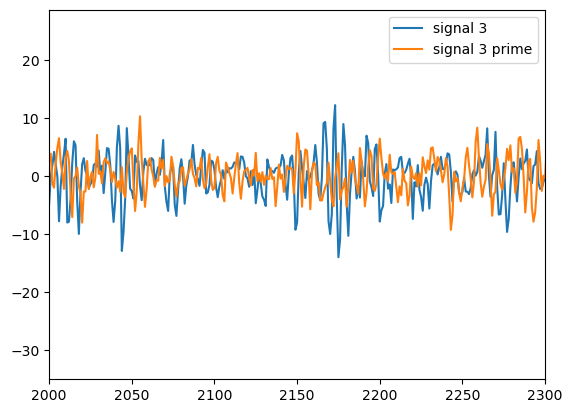

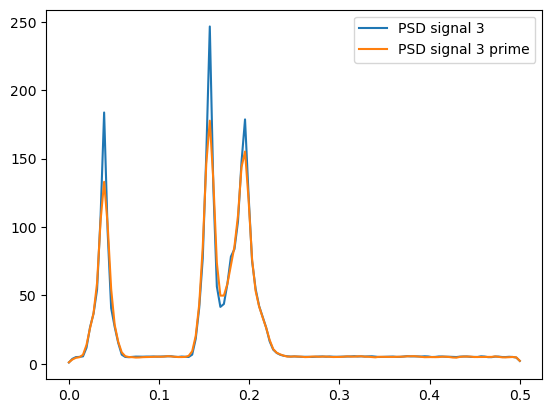

In [12]:
_, signal_3_welch_psd_2sided = sp.signal.welch(signal_3, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=False)
signal_3prime = generate_realization_from_PSD(psd=signal_3_welch_psd_2sided, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

plt.figure()
plt.plot(signal_3, label="signal 3")
plt.plot(signal_3prime, label="signal 3 prime")
start=2000
length=300
plt.xlim([start,start+length])
plt.legend()
plt.show()

signal_3prime_welch_freq, signal_3prime_welch_psd = sp.signal.welch(signal_3prime, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_3_welch_freq, signal_3_welch_psd, label="PSD signal 3")
plt.plot(signal_3prime_welch_freq, signal_3prime_welch_psd, label="PSD signal 3 prime")
plt.legend()
plt.show()

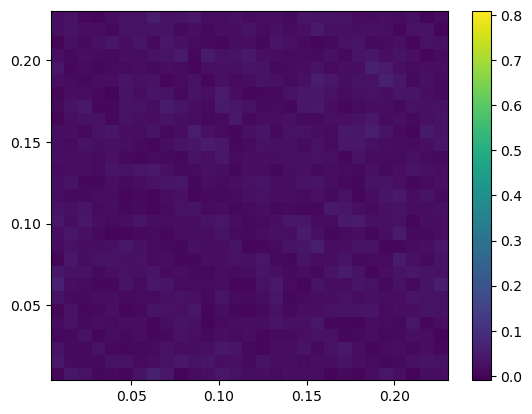

In [13]:
method = "square_norm"

f1_s3prime, f2_s3prime, ch_s3prime = compute_auto_bicoherence(signal_3prime, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3prime, f2_s3prime, np.transpose(ch_s3prime), shading='nearest')
plt.colorbar()
plt.clim([-0.01,0.81])
plt.show()